# Where the coupled fit starts: every supported initializer at one budget

One pass over *starting* a fit of the coupled spatio-sequential model (issue
#887). Every start the package carries is run from its own seam, at one
`Budget`, through one loop, and read against the truth that generated the
data. Every claim here is one the regression suite establishes at a stated bound
(`tests/regression/search/test_projection_seeding.py`,
`tests/regression/search/test_spatio_sequential_fit.py`,
`tests/regression/qa/test_qa_mixture_seeding.py`); this notebook states nothing
the suite does not.

**Two instances, because one referee does not reach both.** The enumerable
coupled instance --- `spatio_sequential/ci`, a 2x2 open lattice, two classes,
two chain states, six positions, 65,536 joint states --- has an *exact*
evidence, and categorical emissions. The seedings of experiment 009 read the
two-channel count emission and are typed for it, so they are defined on the
projection of `spatio_sequential_counts/ci` and not on the categorical
instance. The notebook runs each where it is defined and says which referee it
rests on: the enumerated evidence for the coupled fit, and the generating
parameters' own value for the projected one, which
`tests/regression/search/test_projection_seeding.py` records as the only exact
statement available there.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.likelihood.device import CROSS_DEVICE_RTOL_FLOAT64
from snakes_and_ladders.likelihood.spatio_sequential import (
    enumerate_spatio_sequential,
    log_evidence_by_forward,
    map_labelling,
)
from snakes_and_ladders.opt.budget import Budget, compare
from snakes_and_ladders.opt.initialize import (
    FromObjective,
    Perturbed,
    RandomRestart,
    quantile_locations,
)
from snakes_and_ladders.opt.mixture import (
    mixture_log_likelihood,
    responsibilities,
    seeding_guarantee,
)
from snakes_and_ladders.qa import coupled_labelling, mixture_seeding
from snakes_and_ladders.qa.style import discrete_palette, notebook_style
from snakes_and_ladders.sample.schedule import ExponentialTempSchedule
from snakes_and_ladders.search.projection import (
    SEEDINGS,
    CountPairAt,
    SeededFit,
    Seeding,
    fit_projection,
    flatten,
    project,
    seed_at_means,
    surrogate,
)
from snakes_and_ladders.search.spatio_sequential import (
    fit_spatio_sequential,
    graph_burn_in,
    label_accuracy,
    seed_emissions,
)
from snakes_and_ladders.sim.count_pairs import TOTAL, binned_model
from snakes_and_ladders.sim.fixtures import fixture
from snakes_and_ladders.sim.spatio_sequential import simulate_spatio_sequential
from snakes_and_ladders.track import MemoryRun, track

np.set_printoptions(precision=3, suppress=True)

# The seed every draw and every start in this notebook is taken under, so one
# number states what the printed table depends on.
SEED = 887

## The enumerable instance, and the evidence that referees it

`spatio_sequential/ci` declares the truth. The labelling is the two-stripe
planting `qa.coupled_labelling` draws and the suite plants; the observations
are one draw under it. Enumeration sums the joint over every labelling and
every joint chain path, and is checked against a route that shares no code
with it: given the labels the classes decouple, so the evidence is a sum over
labellings of the per-class forward recursion.

In [2]:
coupled = fixture("spatio_sequential", "ci").params
planted = coupled_labelling.planted_labelling(coupled)
drawn = simulate_spatio_sequential(
    coupled, np.random.default_rng(coupled_labelling.DRAW_SEED), labels=planted
)
states = (
    2**coupled.graph.n_nodes
    * (coupled.n_states**coupled.n_positions) ** coupled.n_classes
)
print(
    "nodes",
    coupled.graph.n_nodes,
    "classes",
    coupled.n_classes,
    "states",
    coupled.n_states,
    "positions",
    coupled.n_positions,
    "joint states",
    states,
)
print("planted labelling", planted)

exact = enumerate_spatio_sequential(coupled, drawn.observations)
forward = log_evidence_by_forward(coupled, drawn.observations)
print("log evidence by enumeration", round(exact.log_evidence, 6))
print("log evidence by forward    ", round(forward, 6))
# The residual itself is not a measurement -- it moves by orders of magnitude
# between machines while every digit above agrees -- so what is printed is the
# tolerance the suite pins this same comparison at (docs/nb/README.md).
print(
    f"the two routes agree within {CROSS_DEVICE_RTOL_FLOAT64:.0e} relative:",
    abs(exact.log_evidence - forward) <= CROSS_DEVICE_RTOL_FLOAT64 * abs(forward),
)
print("MAP labelling", map_labelling(coupled, drawn.observations), " planted", planted)

nodes 4 classes 2 states 2 positions 6 joint states 65536
planted labelling [1 0 1 0]
log evidence by enumeration -22.876874
log evidence by forward     -22.876874
the two routes agree within 1e-11 relative: True
MAP labelling [1 0 1 0]  planted [1 0 1 0]


The QA renderer draws the instance: the planted labelling on the lattice, the
labelling block ascent recovers from the annealed start, and the external
field at the fit. It is `qa.coupled_labelling.build_figure`, the one the
textbook cites as `fig:coupled-labelling` on the 10x10 instance, called here
on the enumerable one; the notebook renders what the package computed and
redraws nothing.

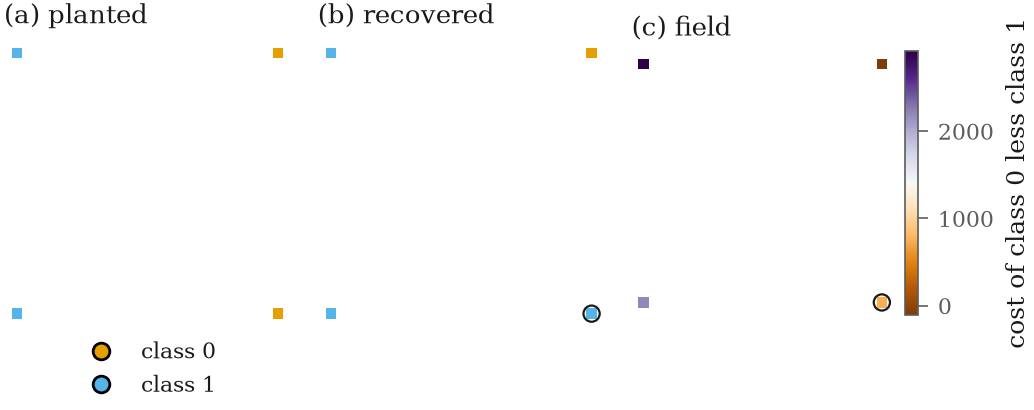

In [3]:
with notebook_style():
    figure, _ = coupled_labelling.build_figure(
        coupled,
        draw_seed=coupled_labelling.DRAW_SEED,
        fit_seed=coupled_labelling.FIT_SEED,
    )
    plt.show()

## The projection, and the reference the starts are read against

Drop the spatial coupling and the chain from the coupled model and each
observation is one draw from a mixture over the `M x K` (class, state) pairs,
which is the surface a seeding of the emission parameters sees. That is where
experiment 009 compared its candidates; the instance here is the **count
fixture's `ci` model at bin factor one**, four components over 4,000
observations, which is the instance
`tests/regression/search/test_projection_seeding.py` holds every candidate to.

A fit of the projection has no exact evidence at any tier, so the reference
every row below is read against is the value the **generating parameters**
reach on this draw. It is not an upper bound: a fit of 4,000 draws may pass it.

Cost is counted in **passes over the data**, one pass being every observation
scored under every component. A fit iteration spends one on its E step; the M
step is not counted, because every start pays the identical one.

In [4]:
declared = fixture("spatio_sequential_counts", "ci").params
model = binned_model(declared.model, 1)
projected = project(model, 4000, np.random.default_rng([541, 0]))
truth = flatten(model)
at = CountPairAt(
    float(truth.total.dispersion.mean()),
    float(truth.successes.concentration.mean()),
    projected.trials,
)

# The six passes of experiment 009: a seeding is a claim about where a fit
# starts, so the fit is held short enough that the claim is still visible in
# where it ends.
BUDGET = Budget(Cost.PASSES, 6)

values = torch.as_tensor(projected.observations, dtype=torch.float64)
log_weight = torch.log(torch.as_tensor(projected.weights, dtype=torch.float64))
REFERENCE = float(mixture_log_likelihood(values, log_weight, truth))
bayes = float(
    np.mean(
        responsibilities(values, log_weight, truth).argmax(dim=1).numpy()
        == projected.components
    )
)
print(
    "components",
    projected.n_components,
    "observations",
    projected.n_samples,
    "budget",
    BUDGET.size,
    BUDGET.unit,
)
print(f"the generating parameters reach {REFERENCE:.1f} nats")
print(f"and assign {bayes:.4f} of observations to their generating component")

components 4 observations 4000 budget 6 passes
the generating parameters reach -32663.2 nats
and assign 0.7795 of observations to their generating component


## One shape per start

Every start ends at the same seam --- it chooses `M x K` locations and
`CountPairAt` places a component on each --- and then runs the same
expectation-maximization loop at the same budget, so what separates two rows
is the choice and nothing after it. Each fit runs inside `track` with a
`MemoryRun`, which records the log-likelihood the fit reports per iteration
and the bytes its state holds; the curves plotted below are read back from
those runs and not from a second loop.

Each row prints, in nats below the reference: the value the start itself sits
at, the value the fit reaches at the budget, the fraction of observations
assigned to their generating component, the largest relative error left in a
component's negative-binomial mean, the passes the start charged, and the
`Termination` the fit ended on.

In [5]:
fits: dict[str, object] = {}
runs: dict[str, MemoryRun] = {}


def start(label: str, rule) -> None:
    """Fit the projection from one start, printing its row and keeping its run."""
    seeding = rule(projected, at, np.random.default_rng([SEED, 0]))
    with track(MemoryRun()) as tracked:
        fitted = fit_projection(
            projected,
            label,
            at,
            BUDGET,
            np.random.default_rng([SEED, 0]),
            seeding=seeding,
        )
    run = tracked.run
    assert isinstance(run, MemoryRun)
    fits[label], runs[label] = fitted, run
    ended = fitted.termination
    print(
        f"{label:11s} seeded {REFERENCE - fitted.log_likelihoods[0]:9.1f} "
        f" reached {REFERENCE - fitted.log_likelihood:7.1f} "
        f" recovery {fitted.recovery:.4f}  mean error {fitted.mean_error:.3f} "
        f" {fitted.seeding.passes:6.1f} passes "
        f" {ended.reason.value} after {ended.iterations} "
        f" state {int(run.last('state_bytes'))} bytes"
    )


print(f"gaps are nats below the {REFERENCE:.1f} the generating parameters reach")

gaps are nats below the -32663.2 the generating parameters reach


### (a) The prior draw and the data draw

The two controls, both free. `prior_seeding` reads no observation: a mean
log-uniform on the observed total range and a rate uniform on the family's own
support. `data_seeding` places a component on each of `M x K` observations
drawn uniformly without replacement, which the suite pins equal to
`opt.mixture.uniform_seeds` draw for draw --- it is the uniform control that
k-means++ is measured against.

In [6]:
start("prior", SEEDINGS["prior"])
start("data", SEEDINGS["data"])

prior       seeded   22595.1  reached   272.6  recovery 0.4570  mean error 0.348     0.0 passes  budget after 6  state 192 bytes


data        seeded    7262.7  reached    53.2  recovery 0.6165  mean error 0.349     0.0 passes  budget after 6  state 192 bytes


### (b) k-means++, and the guarantee it comes with

`euclidean_seeding` is D-squared sampling under squared Euclidean distance ---
`opt.mixture.kmeans_plus_plus`'s score over two channels rather than one, draw
for draw. Its published guarantee is a statement about the *k-means cost* and
not about this likelihood: the expected cost of a k-means++ seeding is within
`8 (ln k + 2)` of the exact optimum. That optimum is the one-dimensional
dynamic programme, whose `O(n^2 k)` cost is past this notebook's budget at
4,000 totals, so the ratio is read through `qa.mixture_seeding.seeding_ratios`
on the first 1,000 totals of the same draw.

In [7]:
start("kmeans++", SEEDINGS["kmeans++"])

GUARANTEE_SAMPLES = 1000
totals = np.asarray(projected.observations, dtype=np.float64)[:, TOTAL]
ratios = mixture_seeding.seeding_ratios(
    totals[:GUARANTEE_SAMPLES], projected.n_components, np.random.default_rng([SEED, 1])
)
print(
    f"over {GUARANTEE_SAMPLES} totals and "
    f"{len(ratios.kmeans_plus_plus)} seedings each, as a factor of the exact optimum"
)
print(f"  k-means++       {ratios.kmeans_plus_plus.mean():.3f}")
print(f"  the uniform control {ratios.uniform.mean():.3f}")
print(f"  the published bound  {seeding_guarantee(projected.n_components):.3f}")

kmeans++    seeded    3024.7  reached    23.4  recovery 0.5670  mean error 0.500     1.0 passes  budget after 6  state 192 bytes


over 1000 totals and 200 seedings each, as a factor of the exact optimum
  k-means++       1.787
  the uniform control 4.517
  the published bound  27.090


### (c) `emission++`

`emission_seeding` is the same scheme under the family's own Bregman
divergence, through `opt.emission_mixture.plus_plus_start` (issue #560).
Experiment 009 has it reaching the best projected value on all six of the key
model's instances; at four components it is one row among many.

In [8]:
start("emission++", SEEDINGS["emission++"])

emission++  seeded     907.8  reached     4.4  recovery 0.7455  mean error 0.195     1.0 passes  budget after 6  state 192 bytes


### (d) The Gaussian-mixture EM start

Experiment 010's control: fit a Gaussian mixture to the first channel by
`opt.mixture.expectation_maximization` --- through `qa.mixture_seeding.fitted`,
which runs it from a k-means++ start --- and take its component means as
locations. It charges an iteration a pass, so it is the most expensive start
here that reads no surface.

gaussian-em seeded     409.7  reached     1.9  recovery 0.7595  mean error 0.083   500.0 passes  budget after 6  state 192 bytes
the start's own fit ended budget after 500


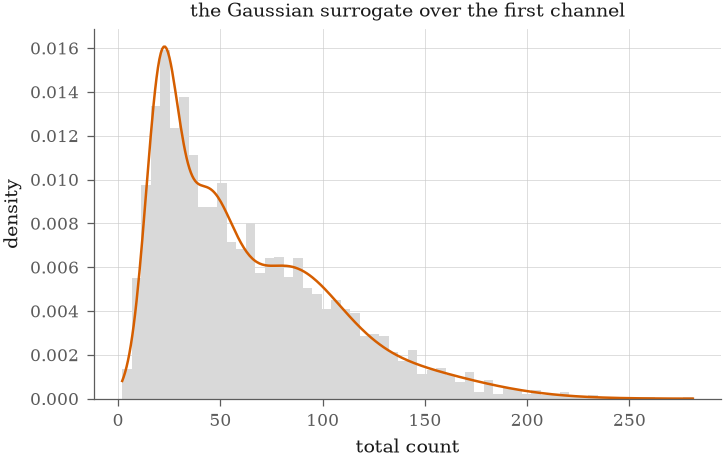

In [9]:
def gaussian_em(instance, seam, rng) -> Seeding:
    """The Gaussian mixture fitted to the first channel, its means the locations."""
    channel = np.asarray(instance.observations, dtype=np.float64)[:, TOTAL]
    fitted = mixture_seeding.fitted(channel, instance.n_components, rng)
    return Seeding(
        seed_at_means(instance, fitted.components.mean, seam),
        float(fitted.iterations),
        f"{fitted.termination.reason.value} after {fitted.iterations}",
    )


start("gaussian-em", gaussian_em)
print("the start's own fit ended", fits["gaussian-em"].seeding.diagnostics)

grid = np.linspace(totals.min(), totals.max(), 400)
control = mixture_seeding.fitted(
    totals, projected.n_components, np.random.default_rng([SEED, 0])
)
with notebook_style():
    figure, axis = plt.subplots(figsize=(5.4, 3.2))
    axis.hist(totals, bins=60, density=True, color="0.85")
    axis.plot(
        grid,
        mixture_seeding.density(grid, control.weights.numpy(), control.components),
        color="#D55E00",
        linewidth=1.2,
    )
    axis.set_xlabel("total count")
    axis.set_ylabel("density")
    axis.set_title("the Gaussian surrogate over the first channel", fontsize=9)
    plt.show()

### (e) The four starts of `opt.initialize`

These take an `Objective` and nothing else, so they run on the surrogate the
projection declares: a Gaussian mixture over the first channel, which is an
`Objective` already. `FromObjective` is the objective's own nominated point,
`Perturbed` that point tilted off a symmetry it may be stationary at,
`RandomRestart` several points drawn around it with the best by surrogate
value kept, and `quantile_locations` the evenly spaced quantiles of the data.
Each yields locations, which `seed_at_means` realizes at the observations
nearest them --- the same step the chain-based starts take.

**Three of the four collapse onto one start, and the seam is what collapses
them.** The surrogate's nominated point *is* the quantile placement, so
`FromObjective` and `quantile_locations` agree by construction; `Perturbed`
tilts that point in unconstrained coordinates by an amount that moves no
location past the observation nearest it, so it reaches the same seeding. The
rows print identically below, which is the measurement and not a repetition:
at four components the tilt `opt/initialize.py` exists to provide --- against
a start that is a stationary point --- does not reach this seam.

In [10]:
#: Restarts drawn, and the spread they are drawn at in unconstrained
#: coordinates. Four, because a restart set costs one surrogate evaluation a
#: start and the budget is six passes.
N_RESTARTS = 4
RESTART_SCALE = 0.5


def from_locations(instance, seam, means, passes: float) -> Seeding:
    """A start that produced locations, realized at the seam every start ends at."""
    return Seeding(seed_at_means(instance, means, seam), passes)


def objective_start(instance, seam, _rng) -> Seeding:
    """The surrogate's own nominated point."""
    objective = surrogate(instance)
    theta = FromObjective().starts(objective)[0]
    return from_locations(instance, seam, objective.components(theta).mean, 0.0)


def perturbed_start(instance, seam, _rng) -> Seeding:
    """That point, tilted off the symmetry it may be stationary at."""
    objective = surrogate(instance)
    theta = Perturbed().starts(objective)[0]
    return from_locations(instance, seam, objective.components(theta).mean, 0.0)


def restart_start(instance, seam, rng) -> Seeding:
    """The best of several points drawn around it, by surrogate value."""
    objective = surrogate(instance)
    thetas = RandomRestart(N_RESTARTS, RESTART_SCALE, rng).starts(objective)
    best = min(thetas, key=lambda theta: float(objective(theta)))
    return from_locations(
        instance, seam, objective.components(best).mean, float(len(thetas))
    )


def quantile_start(instance, seam, _rng) -> Seeding:
    """Evenly spaced quantiles of the first channel."""
    channel = torch.as_tensor(
        np.asarray(instance.observations, dtype=np.float64)[:, TOTAL]
    )
    return from_locations(
        instance, seam, quantile_locations(channel, instance.n_components), 0.0
    )


start("objective", objective_start)
start("perturbed", perturbed_start)
start("restart", restart_start)
start("quantile", quantile_start)

objective   seeded    1459.3  reached     1.2  recovery 0.7485  mean error 0.079     0.0 passes  budget after 6  state 192 bytes


perturbed   seeded    1459.3  reached     1.2  recovery 0.7485  mean error 0.079     0.0 passes  budget after 6  state 192 bytes


restart     seeded     757.5  reached     3.8  recovery 0.7342  mean error 0.061     4.0 passes  budget after 6  state 192 bytes


quantile    seeded    1459.3  reached     1.2  recovery 0.7485  mean error 0.079     0.0 passes  budget after 6  state 192 bytes


### (f) The three starts of `sample.initialize`, and the burn-in

`FromChain` runs a short Hamiltonian chain on the surrogate and keeps its last
draw, `FromAnnealing` the best point of a falling temperature, `FromTempering`
the best point at any temperature of a ladder. All three charge two passes a
gradient and are set to spend the same 72, so what separates them is where the
proposals go. `burn_in_seeding` is what the coupled model's own annealed start
reduces to in projection: a short fit on a subsample.

In [11]:
start("burn-in", SEEDINGS["burn-in"])
start("hmc", SEEDINGS["hmc"])
start("anneal", SEEDINGS["anneal"])
start("tempering", SEEDINGS["tempering"])
print("chain diagnostics")
for label in ("hmc", "anneal", "tempering"):
    print(f"  {label:10s} {fits[label].seeding.diagnostics}")

burn-in     seeded     344.5  reached    24.5  recovery 0.6750  mean error 0.272     0.6 passes  budget after 6  state 192 bytes


hmc         seeded    1074.6  reached    -1.2  recovery 0.7690  mean error 0.031   144.0 passes  budget after 6  state 192 bytes


anneal      seeded    1615.2  reached     2.9  recovery 0.7380  mean error 0.112   144.0 passes  budget after 6  state 192 bytes


tempering   seeded    1273.4  reached    -1.5  recovery 0.7670  mean error 0.049   144.0 passes  budget after 6  state 192 bytes
chain diagnostics
  hmc        acceptance 1.00, mean energy error 3.49e-01
  anneal     acceptance 1.00
  tempering  cold acceptance 1.00, lowest swap 0.00


### (g) `seed_emissions`, which seeds the labels' model and not the components

The eleventh start is the coupled model's own, and it is in its own section
because it is a different object: `Emission_Mixture++` for every class, over
the *categorical* families the enumerable instance carries, feeding
`fit_spatio_sequential`'s block ascent rather than the projected mixture's
loop. It is refereed by the enumerated evidence and by the planted labels,
over six draws of the same instance, against two controls --- the declared
parameters, and `graph_burn_in`, the annealed start whose own seeding this is.

The quantity the fit reports is `log p(x, l | theta)` with the chains
marginalized, at *fitted* parameters; the evidence is `log p(x | theta)` at the
*generating* ones. A gap below zero is therefore not a defect: at four nodes
and six positions the fit has more parameters than the draw constrains.

In [12]:
COUPLED_DRAWS = 6
rows: dict[str, tuple[list[float], list[float]]] = {
    "declared": ([], []),
    "emission++": ([], []),
    "burn-in": ([], []),
}
for index in range(COUPLED_DRAWS):
    draw = simulate_spatio_sequential(
        coupled, np.random.default_rng([SEED, 2, index]), labels=planted
    )
    evidence = enumerate_spatio_sequential(coupled, draw.observations).log_evidence
    seeded = seed_emissions(coupled, draw.observations, np.random.default_rng(index))
    warm = graph_burn_in(
        coupled,
        draw.observations,
        np.random.default_rng(index),
        ExponentialTempSchedule(4.0, 1.0, BUDGET.size),
    )
    for label, params, labels in (
        ("declared", coupled, None),
        ("emission++", seeded, None),
        ("burn-in", warm.params, warm.labels),
    ):
        with track(MemoryRun()) as tracked:
            fit = fit_spatio_sequential(
                params,
                draw.observations,
                np.random.default_rng(index),
                n_blocks=BUDGET.size,
                labels=labels,
            )
        rows[label][0].append(evidence - fit.log_likelihoods[-1])
        rows[label][1].append(label_accuracy(fit.labels, planted, coupled.n_classes))
        coupled_run = tracked.run

print(f"over {COUPLED_DRAWS} draws of the enumerable instance, at {BUDGET.size} blocks")
for label, (gaps, accuracies) in rows.items():
    print(
        f"  {label:11s} evidence less the fitted joint {np.mean(gaps):8.3f} nats "
        f" label accuracy {np.mean(accuracies):.3f}"
    )
print(
    "the last fit ended",
    fit.termination.reason.value,
    "after",
    fit.termination.iterations,
)
print("and its run recorded", len(coupled_run.series("log_likelihood")), "values")

over 6 draws of the enumerable instance, at 6 blocks
  declared    evidence less the fitted joint   -5.485 nats  label accuracy 0.750
  emission++  evidence less the fitted joint   -7.028 nats  label accuracy 0.792
  burn-in     evidence less the fitted joint   -7.493 nats  label accuracy 0.792
the last fit ended budget after 6
and its run recorded 7 values


## What the runs recorded

Two figures, both read from the `MemoryRun` of each start. The first is where
each start put its components and where its fit left them, over the
observations. The second is the amendment's: the fit's iteration against the
gap below the reference, one line per start, with the reference itself the
horizontal line at the bottom of the axis, and beside it the value each start
reached at the budget.

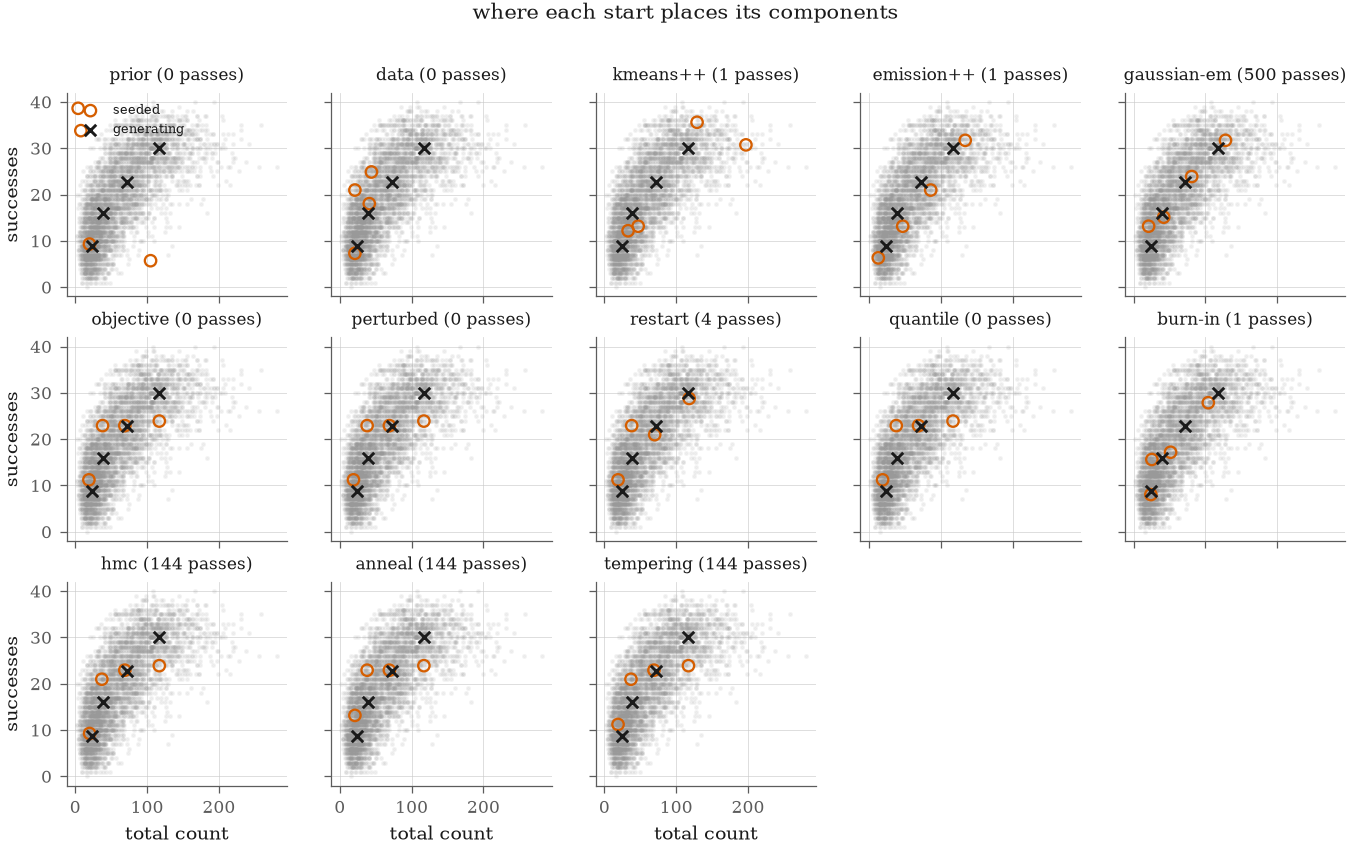

In [13]:
palette = discrete_palette(projected.n_components)
with notebook_style():
    figure, axes = plt.subplots(3, 5, figsize=(11.0, 6.0), sharex=True, sharey=True)
    for axis, (label, fitted) in zip(axes.ravel(), fits.items(), strict=False):
        axis.scatter(
            projected.observations[:, 0],
            projected.observations[:, 1],
            s=2,
            alpha=0.10,
            color="0.6",
        )
        seeded = fitted.seeding.components
        axis.scatter(
            seeded.total.mean.numpy(),
            seeded.successes.mean.numpy(),
            marker="o",
            s=30,
            facecolor="none",
            edgecolor="#D55E00",
            linewidth=1.1,
            label="seeded",
        )
        axis.scatter(
            truth.total.mean.numpy(),
            truth.successes.mean.numpy(),
            marker="x",
            s=30,
            color="0.1",
            label="generating",
        )
        axis.set_title(f"{label} ({fitted.seeding.passes:.0f} passes)", fontsize=8)
    for axis in axes.ravel()[len(fits) :]:
        axis.set_axis_off()
    for axis in axes[-1]:
        axis.set_xlabel("total count")
    for axis in axes[:, 0]:
        axis.set_ylabel("successes")
    axes[0, 0].legend(fontsize=6, loc="upper left")
    figure.suptitle("where each start places its components", fontsize=10)
    plt.show()

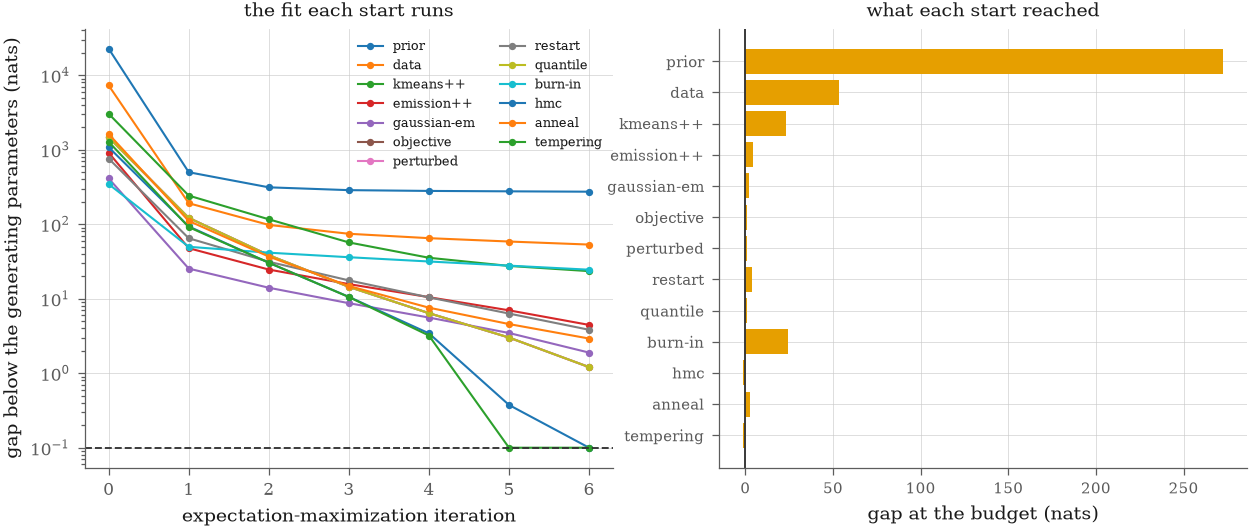

the dashed line is the generating parameters; a bar left of zero passed them


In [14]:
#: Floor on the plotted gap, so a start that passes the reference still has a
#: point on a log axis. A tenth of a nat over 4,000 observations.
GAP_FLOOR = 0.1

with notebook_style():
    figure, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))
    for label in fits:
        recorded = [value for _, value in runs[label].series("log_likelihood")]
        gap = np.maximum(REFERENCE - np.asarray(recorded), GAP_FLOOR)
        axes[0].semilogy(
            range(len(gap)), gap, marker="o", markersize=2.5, linewidth=1.0, label=label
        )
    axes[0].axhline(GAP_FLOOR, color="0.2", linewidth=0.9, linestyle="--")
    axes[0].set_xlabel("expectation-maximization iteration")
    axes[0].set_ylabel("gap below the generating parameters (nats)")
    axes[0].set_title("the fit each start runs", fontsize=9)
    axes[0].legend(fontsize=6, ncol=2)

    reached = [REFERENCE - fits[label].log_likelihood for label in fits]
    axes[1].barh(list(fits), reached, color=palette[0])
    axes[1].axvline(0.0, color="0.2", linewidth=0.9)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("gap at the budget (nats)")
    axes[1].set_title("what each start reached", fontsize=9)
    axes[1].tick_params(labelsize=7)
    plt.show()
print("the dashed line is the generating parameters; a bar left of zero passed them")

## The comparison at an equal budget

`opt.budget.compare` runs every start on the instance at the one budget and
scores each against a reference the caller states --- here the generating
parameters' own value, so a hit is a start that reached the truth's own
likelihood at the table's own tolerance, and the gap is nats below it. The
seeds are this notebook's, so each row is the fit its section printed, which
the last line checks rather than asserts by layout.

Wall clock is not a column. `DEV.md` forbids ranking on host timings and the
notebook checker compares what a cell printed, so a wall column would be the
one number a re-execution could not reproduce; the cost each start spends is
its passes, which the table and the rows above both carry.

In [15]:
RULES = {
    **{label: SEEDINGS[label] for label in SEEDINGS},
    "gaussian-em": gaussian_em,
    "objective": objective_start,
    "perturbed": perturbed_start,
    "restart": restart_start,
    "quantile": quantile_start,
}
comparison = compare(
    {label: SeededFit(label, at, RULES[label]) for label in fits},
    [projected],
    BUDGET,
    [SEED],
    workers=1,
    known=[-REFERENCE],
)
print(comparison.table())
print()
print(f"{'start':11s} {'iterations':>10s} {'seeding passes':>15s} {'state bytes':>12s}")
for label, fitted in fits.items():
    print(
        f"{label:11s} {fitted.termination.iterations:10d} "
        f"{fitted.seeding.passes:15.1f} {int(runs[label].last('state_bytes')):12d}"
    )
print()
print(
    "the comparison reproduces the rows above:",
    all(
        abs(comparison.best[row, 0] + fits[label].log_likelihood) < 1e-9
        for row, label in enumerate(comparison.methods)
    ),
)

| method | hits of 1 | mean gap | passes spent |
| --- | --- | --- | --- |
| prior | 0/1 | 273 | 6 of 6 |
| data | 0/1 | 53.2 | 6 of 6 |
| kmeans++ | 0/1 | 23.4 | 6 of 6 |
| emission++ | 0/1 | 4.45 | 6 of 6 |
| gaussian-em | 0/1 | 1.89 | 6 of 6 |
| objective | 0/1 | 1.21 | 6 of 6 |
| perturbed | 0/1 | 1.21 | 6 of 6 |
| restart | 0/1 | 3.83 | 6 of 6 |
| quantile | 0/1 | 1.21 | 6 of 6 |
| burn-in | 0/1 | 24.5 | 6 of 6 |
| hmc | 1/1 | -1.21 | 6 of 6 |
| anneal | 0/1 | 2.92 | 6 of 6 |
| tempering | 1/1 | -1.47 | 6 of 6 |

start       iterations  seeding passes  state bytes
prior                6             0.0          192
data                 6             0.0          192
kmeans++             6             1.0          192
emission++           6             1.0          192
gaussian-em          6           500.0          192
objective            6             0.0          192
perturbed            6             0.0          192
restart              6             4.0          192
quantile

## Read beside experiment 009

Experiment 009 ran nine of these starts on the **key** model in projection ---
100 components, 4,000 observations, 40 a component --- over six paired
instances. Its two orderings were opposite: `emission++` led the likelihood at
0.4 nats below the best, with the three chain-based starts at 12.1 to 13.4 and
`data` at 15.3, while on recovery `data` and `tempering` beat the prior draw 6
of 6 and lost to it on the likelihood. No default moved (#559).

**Neither ordering is reproduced here, and the two agree.** At four components
over 4,000 observations --- 1,000 a component against the key model's 40 --- the
likelihood ranks the starts `tempering`, `hmc`, the three `opt.initialize`
starts, `gaussian-em`, `anneal`, `restart`, `emission++`, `kmeans++`,
`burn-in`, `data`, `prior`, and recovery ranks them `hmc`, `tempering`,
`gaussian-em`, the `opt.initialize` three, `emission++`, `anneal`, `restart`,
`burn-in`, `data`, `kmeans++`, `prior`. Every start that samples or descends
the surrogate leads on both; `emission++`, which led the key model, is seventh
here; `prior` is last on both where at the key model it was third. So this
table neither confirms nor refutes #559: a ranking at 1,000 observations a
component is not a ranking at 40, which is what that finding says.

**What does carry over is the cost column and the chains' diagnostics.** The
three chain-based starts charge 144 passes against the fit's 6, and buy
`hmc`'s 0.769 recovery over the free `data` start's 0.617 --- a larger buy than
the key model's 0.007, and still a 24x bill. Every chain accepts every proposal
and the tempering ladder's lowest swap acceptance is 0.00, exactly as at the
key model: at 4,000 observations the surrogate is sharp and these are
optimizers, not samplers. `gaussian-em` reaches the same place for its 500
passes, which is the same statement in a second unit.

**Two starts pass the reference.** `hmc` and `tempering` end 1.2 and 1.5 nats
*above* the value the generating parameters reach. The projected likelihood at
the truth is not an upper bound on a fitted one --- it is one point of the
surface, and 4,000 draws leave room above it --- so a start that passes it has
overfitted rather than found a better truth, which is why the recovery column
is beside the gap and not behind it.

## Further work

- The seedings are scored in projection and not on the coupled fit, because
  the M step at the key instance is out of budget and no coupled instance
  exists between the counts `ci` model and the key one: issue #555.
- Spectral seeding by moment inversion, the sixth candidate of #541, is not
  among the starts because no implementation exists: issue #554.
- The `ci` instance orders the likelihood and the truth together where the key
  model orders them oppositely, so nothing here moves a default: issue #559.
- `seed_emissions` is in its own section rather than the table, since it seeds
  the class labels' model over categorical families and not the projected
  mixture's components; whether the two belong in one table is the open
  question of issue #887.
- The enumerable instance carries categorical emissions and the seedings are
  typed for the two-channel count emission, so no single instance here carries
  both the exact evidence and the starts: issue #555.
- The count-pair coupled instance has no notebook of its own, and this one is
  the seventh of the eighteen catalogue rows: issue #682.